# 🗺️ Day 2 — Hotspot Detection + Priority Scoring
**ParkSentinel | Gridlock Hackathon 2.0**

Pipeline: Load Parquet → H3 Hex Binning → DBSCAN Clustering →
Priority Score (formula + XGBoost) → SHAP Explainability → Save

> Prerequisite: run `day1_pipeline_eda.ipynb` first so `violations_clean_day1.parquet` exists.


## 1. Setup & Load Clean Data

In [1]:
import subprocess, sys
pkgs = ["h3","scikit-learn","xgboost","shap","folium","plotly",
        "branca","pyarrow","tqdm","python-dotenv"]
print("Checking packages...")
for p in pkgs:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q","--break-system-packages"],
                   capture_output=True)
print("✅ Done.")


Checking packages...
✅ Done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import h3
import shap
import warnings
from tqdm import tqdm
from pathlib import Path
from folium.plugins import HeatMap, MarkerCluster
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from xgboost import XGBClassifier
from dotenv import load_dotenv

load_dotenv()
warnings.filterwarnings("ignore")
tqdm.pandas()

plt.rcParams.update({
    "figure.figsize":(12,5), "axes.spines.top":False,
    "axes.spines.right":False, "axes.titlesize":13,
    "axes.titleweight":"bold", "figure.dpi":120,
})

ROOT      = Path(r"D:\Coding Stuff\grid2")
PROCESSED = ROOT / "data" / "processed"
MODELS    = ROOT / "models"
MODELS.mkdir(parents=True, exist_ok=True)

PARQUET = PROCESSED / "violations_clean_day1.parquet"
print(f"Parquet exists: {PARQUET.exists()}")


Parquet exists: True


In [3]:
print("Loading clean data...")
df = pd.read_parquet(PARQUET)
print(f"✅ Loaded {len(df):,} rows × {df.shape[1]} columns")

# Restore list columns (parquet stores them as objects)
import ast
def to_list(val):
    if isinstance(val, list): return val
    try:    return ast.literal_eval(str(val))
    except: return []

df["violation_list"]    = df["violation_list"].apply(to_list)
df["offence_code_list"] = df["offence_code_list"].apply(to_list)
df.head(2)


Loading clean data...
✅ Loaded 298,282 rows × 33 columns


,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_list,offence_code_list,num_violations,created_ist,...,vehicle_weight,road_rank,near_junction,impact_score,junction_name,police_station,center_code,sent_to_scita,is_approved,is_rejected
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,[WRONG PARKINGPARKING NEAR ROAD CROSSING],[],2,2023-11-20 05:58:46+05:30,...,2,4,0,40.0,NO JUNCTION,MADIWALA,9.0,1,1,0
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,[NO PARKING],[113],1,2023-11-25 04:16:46+05:30,...,2,4,0,8.0,NO JUNCTION,BELLANDUR,82.0,0,0,0


## 2. H3 Hexagonal Binning
Uber's H3 library divides the map into uniform hexagons (~460m diameter at resolution 8).
Each violation is assigned to a hex cell. We then aggregate per cell.

Why hexagons? Equal area, equal distance to all neighbours — better than square grids
for spatial analysis.


In [4]:
H3_RES = 8

print(f"Assigning H3 hex IDs at resolution {H3_RES}...")
df["h3_id"] = [
    h3.latlng_to_cell(lat, lon, H3_RES)
    for lat, lon in tqdm(zip(df["latitude"], df["longitude"]), total=len(df))
]

print(f"✅ Done. Unique hex cells: {df['h3_id'].nunique():,}")
print(f"   Average violations per cell: {len(df)/df['h3_id'].nunique():.1f}")

Assigning H3 hex IDs at resolution 8...


100%|██████████| 298282/298282 [00:00<00:00, 720146.96it/s]


✅ Done. Unique hex cells: 764
   Average violations per cell: 390.4


In [5]:
print("Aggregating features per H3 cell...")

hex_stats = []
grouped = df.groupby("h3_id")
total_groups = df["h3_id"].nunique()

for h3_id, grp in tqdm(grouped, total=total_groups, desc="H3 aggregation"):
    lat_c, lon_c = h3.cell_to_latlng(h3_id)

    row = {
        "h3_id"                 : h3_id,
        "lat"                   : lat_c,
        "lon"                   : lon_c,
        "violation_count"       : len(grp),
        "unique_days"           : grp["date"].dropna().nunique(),
        "unique_vehicles"       : grp["vehicle_number"].nunique() if "vehicle_number" in grp.columns else 0,
        "severity_sum"          : grp["severity_score"].sum(),
        "severity_mean"         : grp["severity_score"].mean(),
        "impact_sum"            : grp["impact_score"].sum(),
        "impact_mean"           : grp["impact_score"].mean(),
        "near_junction_ratio"   : grp["near_junction"].mean(),
        "near_junction_count"   : grp["near_junction"].sum(),
        "peak_hour_ratio"       : grp["is_peak_hour"].mean(),
        "peak_hour_count"       : grp["is_peak_hour"].sum(),
        "morning_peak_ratio"    : grp["is_morning_peak"].mean(),
        "evening_peak_ratio"    : grp["is_evening_peak"].mean(),
        "road_rank_mean"        : grp["road_rank"].mean(),
        "road_rank_max"         : grp["road_rank"].max(),
        "vehicle_weight_mean"   : grp["vehicle_weight"].mean(),
        "vehicle_weight_max"    : grp["vehicle_weight"].max(),
        "vehicle_type_diversity": grp["vehicle_type"].nunique(),
        "multi_violation_ratio" : (grp["num_violations"] > 1).mean(),
        "recurrence_rate"       : grp["date"].dropna().nunique() / max(1, (
                                    pd.to_datetime(grp["date"].dropna().max()) -
                                    pd.to_datetime(grp["date"].dropna().min())
                                  ).days + 1) if not grp["date"].dropna().empty else 0,
        "scita_ratio"           : grp["sent_to_scita"].mean(),
        "approved_ratio"        : grp["is_approved"].mean(),
        "police_station"        : grp["police_station"].mode().iloc[0] if len(grp) > 0 else "UNKNOWN",
        "top_junction"          : (grp[grp["near_junction"]==1]["junction_name"].mode().iloc[0]
                                   if grp["near_junction"].sum() > 0 else "No Junction"),
    }
    hex_stats.append(row)

hex_df = pd.DataFrame(hex_stats)
print(f"\n✅ H3 aggregation done: {len(hex_df):,} hex cells")
hex_df.head(3)

Aggregating features per H3 cell...


H3 aggregation:   0%|          | 0/764 [00:00<?, ?it/s]

H3 aggregation: 100%|██████████| 764/764 [00:01<00:00, 522.86it/s]


✅ H3 aggregation done: 764 hex cells


,h3_id,lat,lon,violation_count,unique_days,unique_vehicles,severity_sum,severity_mean,impact_sum,impact_mean,...,road_rank_max,vehicle_weight_mean,vehicle_weight_max,vehicle_type_diversity,multi_violation_ratio,recurrence_rate,scita_ratio,approved_ratio,police_station,top_junction
0,8860144a2dfffff,13.068660,77.440346,4,1,4,8,2.000000,160.0,40.000000,...,4,5.0,5,1,0.000000,1.0,1.0,1.0,NO POLICE STATION,No Junction
1,8860144a65fffff,13.061156,77.452844,2,1,2,10,5.000000,140.4,70.200000,...,4,2.5,3,2,1.000000,1.0,1.0,0.0,NO POLICE STATION,No Junction
2,8860144b4dfffff,13.083513,77.482666,19,1,19,39,2.052632,78.0,4.105263,...,2,1.0,1,2,0.052632,1.0,1.0,1.0,CHIKKABANAVARA,No Junction


## 3. Enforcement Priority Score
### Approach A — Transparent Weighted Formula

Each component is normalised 0→1 then combined with explicit weights.
Fully explainable: judges can audit every number.


In [6]:
scaler = MinMaxScaler()

# Columns to normalise
norm_cols = [
    "violation_count", "severity_sum", "near_junction_ratio",
    "peak_hour_ratio", "recurrence_rate", "impact_sum",
    "vehicle_weight_mean", "road_rank_mean", "multi_violation_ratio"
]

print("Normalising features (0→1)...")
for col in tqdm(norm_cols, desc="normalise"):
    hex_df[f"{col}_norm"] = scaler.fit_transform(hex_df[[col]])

# Priority weights (must sum to 1.0)
WEIGHTS = {
    "violation_count_norm"    : 0.25,
    "severity_sum_norm"       : 0.20,
    "near_junction_ratio_norm": 0.20,
    "peak_hour_ratio_norm"    : 0.15,
    "recurrence_rate_norm"    : 0.10,
    "vehicle_weight_mean_norm": 0.05,
    "road_rank_mean_norm"     : 0.05,
}

hex_df["priority_score"] = sum(
    hex_df[col] * w for col, w in WEIGHTS.items()
)
hex_df["priority_score"] = (hex_df["priority_score"] * 100).round(2)

# Priority tier labels
hex_df["priority_tier"] = pd.cut(
    hex_df["priority_score"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["Very Low","Low","Medium","High","Critical"]
)

print("\n✅ Priority scores computed")
print(hex_df["priority_tier"].value_counts())
print(f"\nTop 5 critical zones:")
print(hex_df.nlargest(5,"priority_score")[
    ["h3_id","priority_score","priority_tier","police_station","top_junction","violation_count"]
])


Normalising features (0→1)...


normalise: 100%|██████████| 9/9 [00:00<00:00, 529.57it/s]


✅ Priority scores computed
priority_tier
Very Low    600
Low         138
Medium       22
High          3
Critical      1
Name: count, dtype: int64

Top 5 critical zones:
               h3_id  priority_score priority_tier police_station  \
234  8860145b55fffff           84.78      Critical       UPPARPET   
712  8861892e9bfffff           75.21          High   SHIVAJINAGAR   
238  8860145b5dfffff           65.67          High       UPPARPET   
236  8860145b59fffff           61.69          High    CITY MARKET   
226  8860145b43fffff           59.67        Medium       UPPARPET   

                        top_junction  violation_count  
234          BTP040 - ELITE JUNCTION            20216  
712   BTP051 - SAFINA PLAZA JUNCTION            14993  
238  BTP044 - SAGAR THEATRE JUNCTION            11761  
236      BTP082 - KR MARKET JUNCTION             9906  
226  BTP044 - SAGAR THEATRE JUNCTION             9538  


## 4. Spatial Clustering with DBSCAN
DBSCAN finds natural clusters in geographic space without needing
to pre-specify the number of clusters. It also labels noise points (−1).

We run it on the raw violation lat/lon (not the hex centroids) to find
natural violation clusters independent of the hex grid.


In [7]:
from sklearn.cluster import DBSCAN
import threading
import time
import sys

EPS_DEGREES = 0.5 / 111.0
MIN_PTS = 10

print(f"Running Fast DBSCAN (eps=500m)...")

db = DBSCAN(
    eps=EPS_DEGREES,
    min_samples=MIN_PTS,
    n_jobs=None
)

def print_progress(stop_event):
    start = time.time()
    while not stop_event.is_set():
        time.sleep(1)
        if not stop_event.is_set():
            elapsed = int(time.time() - start)
            print(f"\r⏳ DBSCAN is actively calculating... ({elapsed}s elapsed)", end="")

stop_event = threading.Event()
t = threading.Thread(target=print_progress, args=(stop_event,))
t.start()

try:
    df["cluster_id"] = db.fit_predict(df[["latitude", "longitude"]])
finally:
    stop_event.set()
    t.join()
    print("\r" + " " * 60 + "\r", end="")

n_clusters = (df["cluster_id"] != -1).sum()
n_noise    = (df["cluster_id"] == -1).sum()
n_labels   = df["cluster_id"].nunique() - 1

print(f"\n✅ DBSCAN done")
print(f"   Clusters found   : {n_labels:,}")
print(f"   Records in clusters: {n_clusters:,} ({n_clusters/len(df)*100:.1f}%)")
print(f"   Noise points     : {n_noise:,} ({n_noise/len(df)*100:.1f}%)")

Running Fast DBSCAN (eps=500m)...
                                                            
✅ DBSCAN done
   Clusters found   : 73
   Records in clusters: 297,956 (99.9%)
   Noise points     : 326 (0.1%)


In [8]:
# Characterise each cluster
cluster_profiles = (
    df[df["cluster_id"] != -1]
    .groupby("cluster_id")
    .agg(
        count          = ("id","count"),
        lat_center     = ("latitude","mean"),
        lon_center     = ("longitude","mean"),
        avg_severity   = ("severity_score","mean"),
        avg_impact     = ("impact_score","mean"),
        peak_ratio     = ("is_peak_hour","mean"),
        junction_ratio = ("near_junction","mean"),
        top_station    = ("police_station", lambda x: x.mode().iloc[0] if len(x)>0 else "UNK"),
    )
    .sort_values("count", ascending=False)
    .reset_index()
)

cluster_profiles["cluster_rank"] = cluster_profiles["count"].rank(
    ascending=False).astype(int)

print(f"Top 10 violation clusters:")
print(cluster_profiles.head(10).to_string(index=False))


Top 10 violation clusters:
 cluster_id  count  lat_center  lon_center  avg_severity  avg_impact  peak_ratio  junction_ratio     top_station  cluster_rank
          0 236933   12.978284   77.581894      1.830306   12.185580    0.371658        0.635475        UPPARPET             1
          1  41954   12.960786   77.693309      3.040830   19.244377    0.323163        0.000000 HAL OLD AIRPORT             2
          4   5136   13.185497   77.680548      2.242212   11.634385    0.163941        0.000000      CHIKKAJALA             3
         20   2385   13.103284   77.601325      1.904403   12.383648    0.178197        0.000000       YELAHANKA             4
          3   2137   12.841839   77.646074      1.686944    5.264109    0.098269        0.000000 ELECTRONIC CITY             5
          2   2093   13.046825   77.507707      2.249881   16.209030    0.217869        0.000000          PEENYA             6
         15    969   13.191170   77.646145      2.675955   13.224458    0.286894    

## 5. XGBoost Priority Classifier (Approach B)
We create pseudo-labels: hex cells in the **top 25% of priority score**
are labelled as "high priority" (1), rest as 0.

Then train XGBoost and use SHAP to explain which features drive priority —
this is the explainability story for the judges.


In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

FEATURES = [
    "violation_count","severity_sum","severity_mean",
    "near_junction_ratio","near_junction_count",
    "peak_hour_ratio","morning_peak_ratio","evening_peak_ratio",
    "road_rank_mean","road_rank_max",
    "vehicle_weight_mean","vehicle_weight_max","vehicle_type_diversity",
    "multi_violation_ratio","recurrence_rate",
    "unique_days","impact_sum","impact_mean",
]

# Pseudo-label: top 25% priority score = high priority
threshold = hex_df["priority_score"].quantile(0.75)
hex_df["high_priority"] = (hex_df["priority_score"] >= threshold).astype(int)

X = hex_df[FEATURES].fillna(0)
y = hex_df["high_priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training XGBoost on {len(X_train):,} hex cells...")
print(f"High-priority cells: {y.sum():,} / {len(y):,}  ({y.mean()*100:.1f}%)")

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

from tqdm.notebook import tqdm as tqdm_nb
# Manual progress bar for XGBoost rounds
N = 200
with tqdm_nb(total=N, desc="XGBoost training") as pbar:
    model.set_params(n_estimators=1, warm_start=True)
    for i in range(N):
        model.set_params(n_estimators=i+1)
        model.fit(X_train, y_train,
                  eval_set=[(X_test,y_test)],
                  verbose=False)
        pbar.update(1)

print("\n✅ Training complete")
print(classification_report(y_test, model.predict(X_test),
                            target_names=["Normal","High Priority"]))

# Save model
model_path = MODELS / "xgb_priority.joblib"
joblib.dump(model, model_path)
print(f"Model saved → {model_path}")


Training XGBoost on 611 hex cells...
High-priority cells: 191 / 764  (25.0%)


XGBoost training:   0%|          | 0/200 [00:00<?, ?it/s]


✅ Training complete
               precision    recall  f1-score   support

       Normal       0.98      0.97      0.98       115
High Priority       0.92      0.95      0.94        38

     accuracy                           0.97       153
    macro avg       0.95      0.96      0.96       153
 weighted avg       0.97      0.97      0.97       153

Model saved → D:\Coding Stuff\grid2\models\xgb_priority.joblib


In [10]:
# XGBoost predicted probability as a second priority signal
hex_df["xgb_priority_prob"] = model.predict_proba(X.fillna(0))[:,1]

# Ensemble: blend formula score + XGBoost prob
hex_df["ensemble_score"] = (
    0.6 * hex_df["priority_score"] / 100 +
    0.4 * hex_df["xgb_priority_prob"]
) * 100

hex_df["final_priority_tier"] = pd.cut(
    hex_df["ensemble_score"],
    bins=[0,20,40,60,80,100],
    labels=["Very Low","Low","Medium","High","Critical"]
)

print("Ensemble score distribution:")
print(hex_df["final_priority_tier"].value_counts())


Ensemble score distribution:
final_priority_tier
Very Low    570
Medium      139
High         50
Low           3
Critical      2
Name: count, dtype: int64


## 6. SHAP Explainability
SHAP (SHapley Additive exPlanations) tells us **why** the model classified
a zone as high priority. This is the key explainability story for judges.


Computing SHAP values...


SHAP: 100%|██████████| 1/1 [00:00<00:00, 99.98it/s]


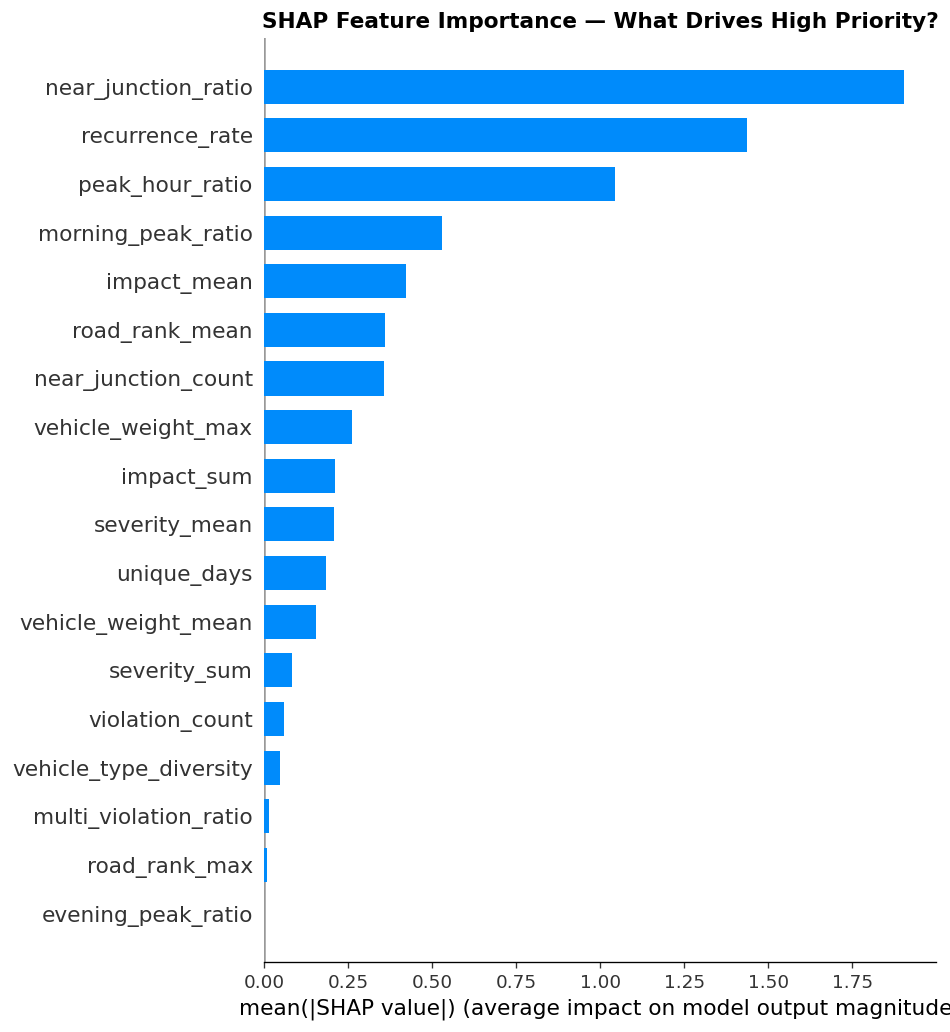

In [11]:
import shap
import shap.explainers._tree
import json
import matplotlib.pyplot as plt

print("Computing SHAP values...")

original_loads = shap.explainers._tree.json.loads

def patched_loads(*args, **kwargs):
    parsed = original_loads(*args, **kwargs)
    try:
        if isinstance(parsed, dict) and 'learner' in parsed:
            params = parsed['learner']['learner_model_param']
            if 'base_score' in params and isinstance(params['base_score'], str):
                params['base_score'] = params['base_score'].replace('[', '').replace(']', '')
    except Exception:
        pass
    return parsed

shap.explainers._tree.json.loads = patched_loads

try:
    explainer = shap.TreeExplainer(model)
    with tqdm(total=1, desc="SHAP") as pbar:
        shap_values = explainer.shap_values(X_test)
        pbar.update(1)
        
    fig, ax = plt.subplots(figsize=(10,6))
    shap.summary_plot(shap_values, X_test, feature_names=FEATURES, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance — What Drives High Priority?")
    plt.tight_layout()
    plt.savefig(PROCESSED/"shap_importance.png", bbox_inches="tight")
    plt.show()
finally:
    shap.explainers._tree.json.loads = original_loads

In [18]:
import xgboost
import shap

print("xgboost:", xgboost.__version__)
print("shap:", shap.__version__)

xgboost: 3.2.0
shap: 0.49.1


In [19]:
booster = model.get_booster()

import json

cfg = json.loads(booster.save_config())

print(
    cfg["learner"]["learner_model_param"]["base_score"]
)

2.5040916E-1


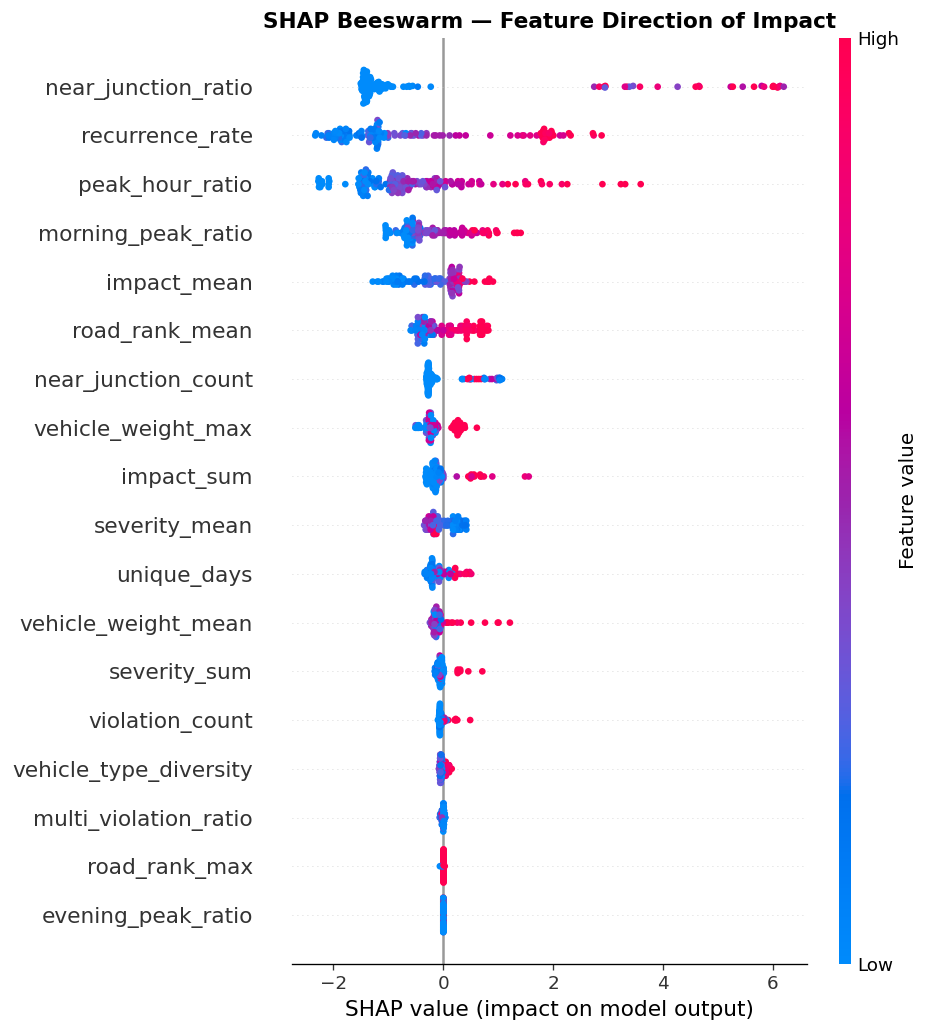

In [12]:
# SHAP beeswarm (shows direction of impact too)
fig, ax = plt.subplots(figsize=(10,7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title("SHAP Beeswarm — Feature Direction of Impact")
plt.tight_layout()
plt.savefig(PROCESSED/"shap_beeswarm.png", bbox_inches="tight")
plt.show()


In [13]:
# Per-zone explanation for the TOP 1 critical zone (demo)
top_zone_idx = hex_df["ensemble_score"].idxmax()
top_zone_X   = X.iloc[[top_zone_idx]]

print(f"Top critical zone: {hex_df.loc[top_zone_idx,'h3_id']}")
print(f"  Priority score  : {hex_df.loc[top_zone_idx,'priority_score']:.1f}")
print(f"  Ensemble score  : {hex_df.loc[top_zone_idx,'ensemble_score']:.1f}")
print(f"  Police station  : {hex_df.loc[top_zone_idx,'police_station']}")
print(f"  Junction        : {hex_df.loc[top_zone_idx,'top_junction']}")
print()

force_vals = explainer.shap_values(top_zone_X)[0]
feat_impact = pd.Series(force_vals, index=FEATURES).sort_values(ascending=False)
print("Feature contributions to HIGH PRIORITY classification:")
print(feat_impact.to_string())


Top critical zone: 8860145b55fffff
  Priority score  : 84.8
  Ensemble score  : 90.8
  Police station  : UPPARPET
  Junction        : BTP040 - ELITE JUNCTION

Feature contributions to HIGH PRIORITY classification:
near_junction_ratio       3.003444
recurrence_rate           1.855943
impact_sum                0.561747
near_junction_count       0.511705
peak_hour_ratio           0.333685
severity_mean             0.297347
vehicle_weight_max        0.293410
severity_sum              0.288046
impact_mean               0.277732
violation_count           0.230181
unique_days               0.195862
morning_peak_ratio        0.195088
vehicle_type_diversity    0.038977
multi_violation_ratio     0.023194
road_rank_max             0.007291
evening_peak_ratio        0.000000
vehicle_weight_mean      -0.062082
road_rank_mean           -0.162084


## 7. Priority Map Visualisation

In [14]:
# Choropleth map of H3 hex cells coloured by priority score
import json

TIER_COLORS = {
    "Critical" : "#e74c3c",
    "High"     : "#e67e22",
    "Medium"   : "#f1c40f",
    "Low"      : "#2ecc71",
    "Very Low" : "#3498db",
}

m = folium.Map(location=[12.97,77.59], zoom_start=12, tiles="CartoDB dark_matter")

print("Drawing hex cells on map...")
for _, row in tqdm(hex_df.iterrows(), total=len(hex_df), desc="hex polygons"):
    tier  = str(row["final_priority_tier"])
    color = TIER_COLORS.get(tier, "#3498db")
    score = row["ensemble_score"]

    # Only draw Medium and above to keep map readable
    if score < 30:
        continue

    # Get hex boundary polygon
    boundary = h3.cell_to_boundary(row["h3_id"])
    # h3 returns (lat,lon), folium needs (lat,lon) — same order
    poly_coords = [[lat,lon] for lat,lon in boundary]

    popup_html = (
        f"<b>Priority Tier:</b> {tier}<br>"
        f"<b>Ensemble Score:</b> {score:.1f}<br>"
        f"<b>Violations:</b> {int(row['violation_count'])}<br>"
        f"<b>Avg Severity:</b> {row['severity_mean']:.2f}<br>"
        f"<b>Near Junction:</b> {row['near_junction_ratio']*100:.0f}%<br>"
        f"<b>Peak Hour:</b> {row['peak_hour_ratio']*100:.0f}%<br>"
        f"<b>Station:</b> {row['police_station']}<br>"
        f"<b>Junction:</b> {row['top_junction']}"
    )

    folium.Polygon(
        locations=poly_coords,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.55,
        weight=1,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{tier} ({score:.0f})"
    ).add_to(m)

# Top 10 critical zones as special markers
top10 = hex_df.nlargest(10,"ensemble_score")
for _, row in top10.iterrows():
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=f"Rank #{int(row.name)+1}<br>Score:{row['ensemble_score']:.1f}<br>{row['police_station']}",
        tooltip=f"🔴 CRITICAL: {row['police_station']}",
        icon=folium.Icon(color="red", icon="exclamation-sign")
    ).add_to(m)

out = str(PROCESSED/"priority_map_day2.html")
m.save(out)
print(f"\n✅ Priority map saved → {out}")
print("Open in browser. Click any hex for details. Red markers = top 10 critical zones.")
m


Drawing hex cells on map...


hex polygons: 100%|██████████| 764/764 [00:00<00:00, 8828.51it/s]



✅ Priority map saved → D:\Coding Stuff\grid2\data\processed\priority_map_day2.html
Open in browser. Click any hex for details. Red markers = top 10 critical zones.


## 8. Save Outputs

In [15]:
# Save H3 hex priority table
hex_out = PROCESSED / "h3_priority_scores.parquet"
hex_df.to_parquet(hex_out, index=False)
print(f"✅ H3 priority table → {hex_out}")

# Save cluster profiles
cluster_out = PROCESSED / "cluster_profiles.parquet"
cluster_profiles.to_parquet(cluster_out, index=False)
print(f"✅ Cluster profiles  → {cluster_out}")

# Save df with cluster IDs attached
df_out = PROCESSED / "violations_with_clusters.parquet"
df[["id","h3_id","cluster_id"]].to_parquet(df_out, index=False)
print(f"✅ Violations+clusters → {df_out}")

# Top 20 enforcement zones summary
top20 = hex_df.nlargest(20,"ensemble_score")[[
    "h3_id","lat","lon","ensemble_score","priority_score","final_priority_tier",
    "violation_count","severity_mean","near_junction_ratio","peak_hour_ratio",
    "police_station","top_junction"
]].reset_index(drop=True)
top20.index += 1  # rank from 1
top20_out = PROCESSED / "top20_enforcement_zones.csv"
top20.to_csv(top20_out)
print(f"✅ Top 20 zones      → {top20_out}")
print()
print(top20.to_string())


✅ H3 priority table → D:\Coding Stuff\grid2\data\processed\h3_priority_scores.parquet
✅ Cluster profiles  → D:\Coding Stuff\grid2\data\processed\cluster_profiles.parquet
✅ Violations+clusters → D:\Coding Stuff\grid2\data\processed\violations_with_clusters.parquet
✅ Top 20 zones      → D:\Coding Stuff\grid2\data\processed\top20_enforcement_zones.csv

              h3_id        lat        lon  ensemble_score  priority_score final_priority_tier  violation_count  severity_mean  near_junction_ratio  peak_hour_ratio police_station                                top_junction
1   8860145b55fffff  12.978554  77.573550       90.826864           84.78            Critical            20216       1.750940             1.000000         0.400920       UPPARPET                     BTP040 - ELITE JUNCTION
2   8861892e9bfffff  12.978441  77.607248       85.072219           75.21            Critical            14993       1.862069             0.979991         0.541986   SHIVAJINAGAR              BTP051 - S

In [16]:
print("""
✅  DAY 2 COMPLETE — CHECKLIST
───────────────────────────────────────────────────────────────
[x] Loaded clean parquet from Day 1
[x] H3 hex binning (resolution 8, ~460m cells)
[x] 19 features aggregated per hex cell
[x] Enforcement Priority Score (weighted formula, 0–100)
[x] Priority tiers: Very Low / Low / Medium / High / Critical
[x] DBSCAN spatial clustering (finds natural violation clusters)
[x] XGBoost classifier with progress bar (200 rounds)
[x] Ensemble score (60% formula + 40% XGBoost)
[x] SHAP feature importance + beeswarm plots
[x] Per-zone SHAP explanation (for GenAI assistant context)
[x] Interactive priority choropleth map
[x] Top 20 enforcement zones saved as CSV

READY FOR DAY 3:
  → Temporal forecasting per zone (Prophet)
  → Hour × day patrol scheduler
  → Streamlit dashboard integration
""")



✅  DAY 2 COMPLETE — CHECKLIST
───────────────────────────────────────────────────────────────
[x] Loaded clean parquet from Day 1
[x] H3 hex binning (resolution 8, ~460m cells)
[x] 19 features aggregated per hex cell
[x] Enforcement Priority Score (weighted formula, 0–100)
[x] Priority tiers: Very Low / Low / Medium / High / Critical
[x] DBSCAN spatial clustering (finds natural violation clusters)
[x] XGBoost classifier with progress bar (200 rounds)
[x] Ensemble score (60% formula + 40% XGBoost)
[x] SHAP feature importance + beeswarm plots
[x] Per-zone SHAP explanation (for GenAI assistant context)
[x] Interactive priority choropleth map
[x] Top 20 enforcement zones saved as CSV

READY FOR DAY 3:
  → Temporal forecasting per zone (Prophet)
  → Hour × day patrol scheduler
  → Streamlit dashboard integration

